# ENCONTRAR LOS MEJORES HIPERPARÁMETROS PARA ENSEMBLES

Hay 3 maneras de encontrar los mejores hiperparámetros: Grid Search, Random Search y Optimización Bayesiana. En este caso, vamos a centrarnos en Optuna. Pondremos la optimización bayesiana en práctica

In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

def objective(trial): # para cada trial TPE elige hiperparametros -> cv -> resultado como media de los folds 
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log= True)
    n_estimators = trial.suggest_int('n_estimators', 50, 300, log = True)
    max_depth = trial.suggest_int('max_depth', 3,10,log =True)

    model_xgboost = XGBClassifier(n_estimators= n_estimators, learning_rate = learning_rate, max_depth = max_depth, random_state =42)

    cv_model_xgboost = cross_val_score(model_xgboost,X_train, y_train, cv = 5, scoring= 'accuracy')

    return cv_model_xgboost.mean()

In [ ]:
study = optuna.create_study(direction='maximize') # información del estudio

study.optimize(objective, n_trials=50) # ejecuta 50 veces la funcion objective, optimize es el bucle que orquesta todo para maximizar el accuracy

[I 2026-04-23 20:59:30,951] A new study created in memory with name: no-name-fb8d0d3d-b5b5-44c7-ac44-6b49d4bc5277
[I 2026-04-23 20:59:32,033] Trial 0 finished with value: 0.9582417582417582 and parameters: {'learning_rate': 0.014556203106072528, 'n_estimators': 126, 'max_depth': 3}. Best is trial 0 with value: 0.9582417582417582.
[I 2026-04-23 20:59:32,750] Trial 1 finished with value: 0.9582417582417582 and parameters: {'learning_rate': 0.016290873522591884, 'n_estimators': 101, 'max_depth': 5}. Best is trial 0 with value: 0.9582417582417582.
[I 2026-04-23 20:59:33,390] Trial 2 finished with value: 0.9604395604395604 and parameters: {'learning_rate': 0.04696598907087467, 'n_estimators': 50, 'max_depth': 4}. Best is trial 2 with value: 0.9604395604395604.
[I 2026-04-23 20:59:34,079] Trial 3 finished with value: 0.9626373626373625 and parameters: {'learning_rate': 0.049614264075672786, 'n_estimators': 172, 'max_depth': 4}. Best is trial 3 with value: 0.9626373626373625.
[I 2026-04-23 20

In [ ]:
study.best_params, study.best_value 

({'learning_rate': 0.2163245243370783, 'n_estimators': 239, 'max_depth': 3},
 0.9692307692307693)

In [5]:
from xgboost import XGBClassifier

model_XGBoost = XGBClassifier(n_estimators = 239, learning_rate = 0.2163245243370783, max_depth = 3,random_state = 42)

train_XGBoost = model_XGBoost.fit(X_train, y_train)

predict_train_XGBoost = model_XGBoost.predict(X_train)

from sklearn.metrics import accuracy_score

accuracy_train_XGBoost = accuracy_score(y_train, predict_train_XGBoost)

print(f"El accuracy en train del modelo XGBoost es", accuracy_train_XGBoost)

predict_test_XGBoost = model_XGBoost.predict(X_test)

accuracy_test_XGBoost = accuracy_score(y_test, predict_test_XGBoost)

print(f"El accuracy en test del modelo XGBoost es", accuracy_test_XGBoost)

El accuracy en train del modelo XGBoost es 1.0
El accuracy en test del modelo XGBoost es 0.956140350877193


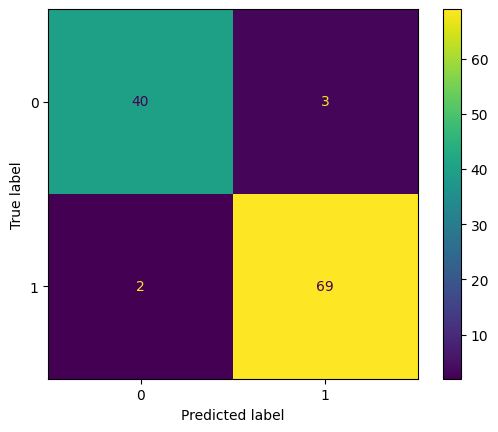

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix = confusion_matrix(y_test, predict_test_XGBoost)

ConfusionMatrixDisplay(confusion_matrix).plot()

Además, tan bueno es un modelo optimizado con los mejores hiperparámetros como un modelo que explica sus predicciones. Para ello empleamos la herramienta SHAP para obtener explicaciones locales y globales del modelo.

In [ ]:
import shap

explication_shap = shap.TreeExplainer(model_XGBoost) # explainer especifico para modelos de arboles 

valores_shap = explication_shap.shap_values(X_test) # para cada observación del test SHAP calcula cuánto contribuyó cada feature a su predicción en el modelo del explainer

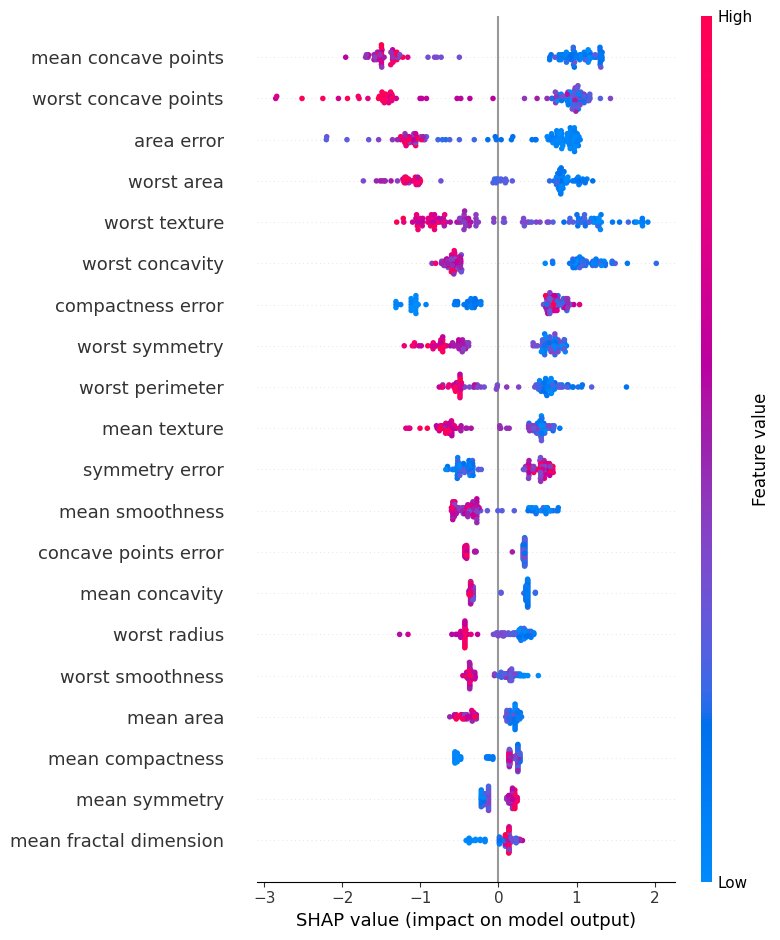

In [12]:
shap.summary_plot(valores_shap, X_test, feature_names= data.feature_names) # para cada feature pinta un punto por observación

In [10]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

Entonces en el gráfico:

Izquierda (SHAP negativo) → empuja hacia clase 0 → maligno

Derecha   (SHAP positivo) → empuja hacia clase 1 → benigno

Entonces para mean concave points:

Puntos rojos a la izquierda → valor alto → empuja hacia maligno 

Puntos azules a la derecha  → valor bajo → empuja hacia benigno 

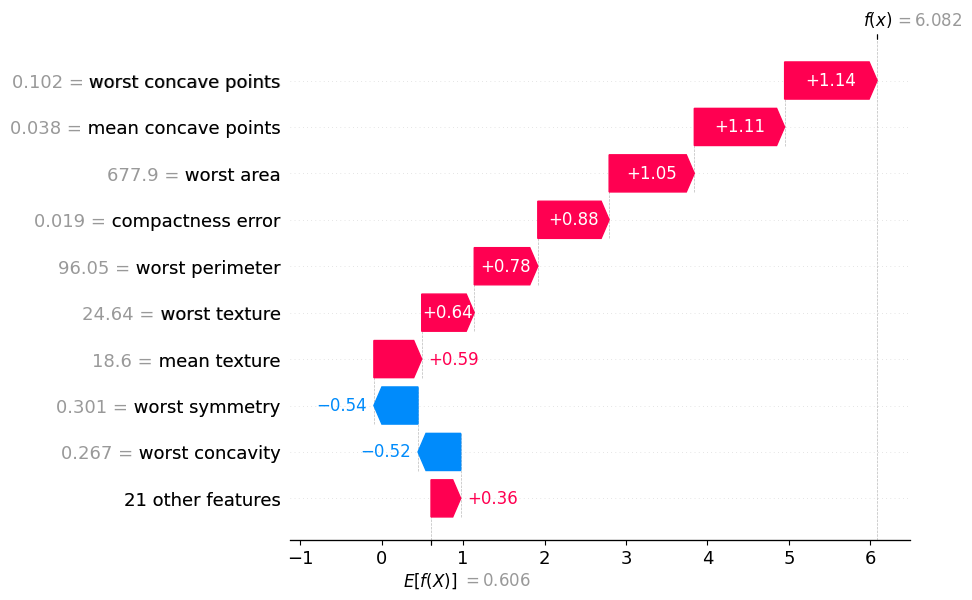

In [16]:
explanation = shap.Explanation(
    values=valores_shap[0],
    base_values=explication_shap.expected_value,
    data=X_test[0],
    feature_names=data.feature_names
)
shap.plots.waterfall(explanation)

In [23]:
import numpy as np

obs_incorrectas = np.where(y_test != predict_test_XGBoost)

obs_incorrectas

(array([  8,  20,  77,  82, 108]),)

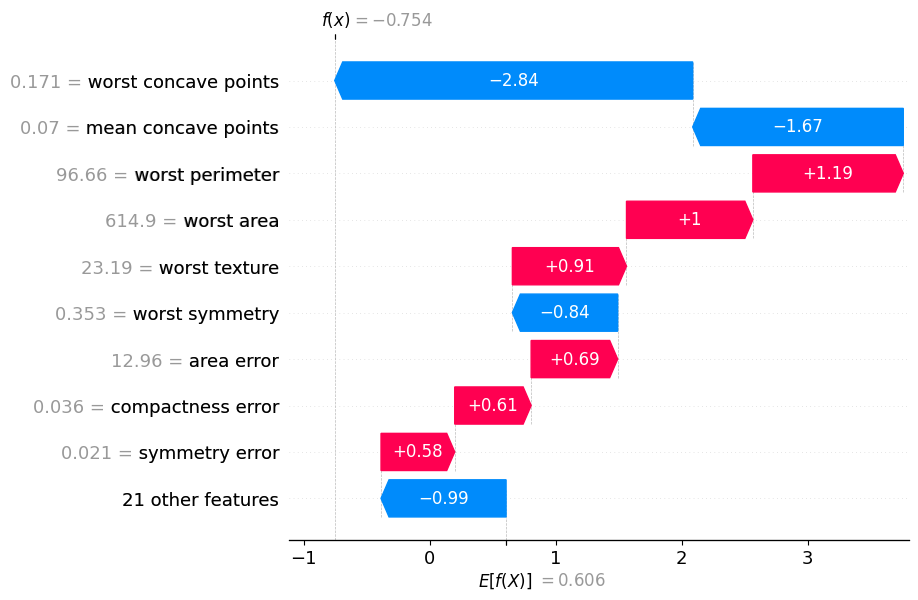

In [25]:
explanation_obs8 = shap.Explanation(
    values=valores_shap[8],
    base_values=explication_shap.expected_value,
    data=X_test[8],
    feature_names=data.feature_names
)
shap.plots.waterfall(explanation_obs8)

El modelo predice maligno pero el valor real es benigno.
Las features de puntos cóncavos tiraron tan fuerte hacia maligno que el modelo se confundió, aunque otras features como worst perimeter y worst area intentaban empujar hacia benigno.

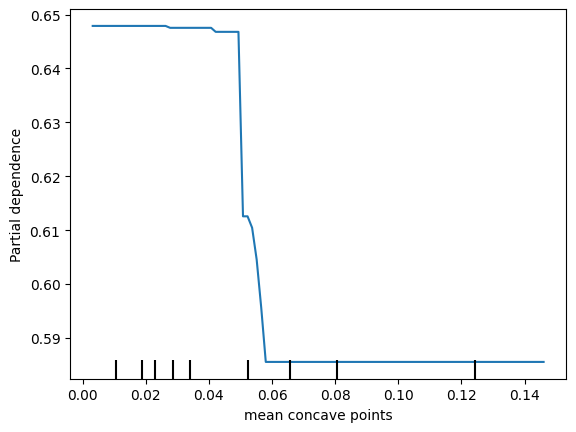

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(model_XGBoost, X_test, [7], feature_names=data.feature_names)

Cuando mean concave points supera ~0.05, el modelo empieza a considerar el tumor más maligno. Por debajo de ese umbral, benigno.
Y tiene sentido con lo que vimos en el Summary Plot — esta feature es la más importante del modelo y su efecto es muy claro y no lineal.